1. Dataset Preparation
1.the shape of dataset:
Number of samples: 100

Number of features per sample: 2 

Number of classes: 2 (binary — 0 or 1)

2. Generate two classes:
Class 0: centered at one point ( around (0,0))

Class 1: centered at another point ( around (1,1))

Add random noise for realism

3. Stack and shuffle:
Combine class 0 and class 1 examples

Shuffle the dataset

5. Normalize :
Scale features between 0 and 1 (min-max scaling)

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
num_samples_per_class=50
num_features=2
class0=np.random.rand(num_samples_per_class,num_features)*0.5+np.array([1,1])
#return matrix with 50*2 and centered around 1,1
class1=np.random.rand(num_samples_per_class,num_features)+np.array([3,3])
#return matrix with 50*2  and centered around 3,3
labels0=np.zeros((num_samples_per_class,1))
labels1=np.ones((num_samples_per_class,1))
#two vectors each 50*1
x=np.vstack((class0,class1))
y=np.vstack((labels0,labels1))
#integrate labels and samples vertically into one matrix and one vector
indices=np.arange(x.shape[0])#array include indices of samples from 0 to 99
np.random.shuffle(indices)#Randomizes the order of the dataset
x=x[indices]#Give me the rows of X at these indices, in this order.”similar to slices like X[:10] for first 10 rows But X[indices] gives you random or custom access to rows.
y=y[indices]
x_min=x.min(axis=0)
x_max=x.max(axis=0)
#return min ,max for each coloumn
x=(x-x_min)/(x_max-x_min)
print("X shape:", x.shape)  # (100, 2)
print("y shape:", y.shape)  # (100, 1)

X shape: (100, 2)
y shape: (100, 1)


In [4]:
print(x_max,x_min)

[3.98565045 3.97178208] [1.00276106 1.02322521]


Network Initialization
Randomly initialize:

Weights W for each layer


In [5]:
def initialize_parameters():
    np.random.seed(42)
    w1=np.random.rand(4,3)#number of neurons for first hidden layer is 4 each neuron as two inputs and bias 
    w2=np.random.rand(1,5)#number of neuron for output is 1 with four outputs from hidden layer and one bias
    return w1,w2

In [6]:
def relu(z):
    return np.maximum(0,z)
def sigmoid(z):
    return 1/(1+np.exp(-z))

Training Loop
Repeat for a number of epochs:

Forward pass

Compute loss

Backpropagation

Update weights

Forward → Loss → Backprop → Update

In machine learning, an epoch refers to one complete pass through the entire training dataset where every data sample is passed through the model and its parameters are updated based on the calculated error. The training process requires multiple epochs, allowing the model to improve iteratively by adjusting its parameters based on the calculated error.


In [ ]:
def train(x,y,learning_rate,epochs):
    w1,w2=initialize_parameters()
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0
        for i in range(x.shape[0]):
            x_sample=x[i].reshape(-1,1)#to make as vector 2*1 
            #-1 tells NumPy: "Infer this dimension automatically"Since we had 2 elements, it reshapes to (2, 1)Figure out how many rows are needed automatically, based on the data and the other dimensions I gave you.”
            y_sample=y[i]
            x_input=np.vstack([x_sample,[[1]]])#1 for bias
            net1=np.dot(w1,x_input)#has shape 4*1
            o1=relu(net1)#has shape 4*1
            input_for_outputlayer=np.vstack([o1,[[1]]])#shape 5*1
            net2=np.dot(w2,input_for_outputlayer)#shape1*1
            o2=sigmoid(net2)
            loss=0.5*(y_sample-o2)**2
            total_loss += loss
            delta_k=(y_sample-o2)*o2*(1-o2)
            deltaj=np.dot(w2[:,:-1].T,delta_k)#exclude bias value shape4*1
            w2+=learning_rate*(np.dot(delta_k,input_for_outputlayer.T))
            w1+=learning_rate*(np.dot(deltaj,x_input.T))
        avg_loss = total_loss / x.shape[0]
        loss_history.append(avg_loss[0][0])
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {loss[0][0]:.4f}")
    
    return w1, w2,loss_history

Epoch 0: Loss = 0.1306
Epoch 10: Loss = 0.0058
Epoch 20: Loss = 0.0022
Epoch 30: Loss = 0.0013
Epoch 40: Loss = 0.0008
Epoch 50: Loss = 0.0006
Epoch 60: Loss = 0.0005
Epoch 70: Loss = 0.0004
Epoch 80: Loss = 0.0003
Epoch 90: Loss = 0.0003


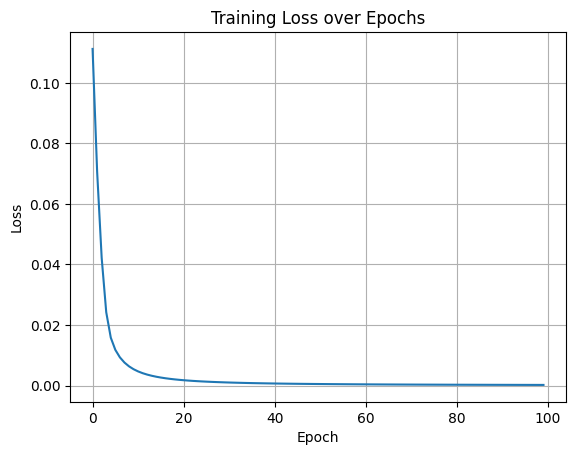

In [10]:
W1, W2, loss_history = train(x, y, epochs=100, learning_rate=0.1)

# Plot
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()



In [11]:
W1,W2

(array([[ 2.06469161,  2.55613743, -1.604527  ],
        [ 1.3510202 ,  0.87021989, -0.83838739],
        [ 0.17917126,  0.98151743,  0.41034875],
        [ 0.02871812, -0.62237776,  1.77305059]]),
 array([[ 2.8848344 ,  1.31919166,  0.31449582, -1.46808236, -1.39886171]]))